## The comparative analysis of CO2 and Greenhouse Gas Emissions

This performs structured comparative analysis of CO2 and greenhouse gas emissions using the post 1960 dataset identified during exploratory data analysis. The purpose of this analysis is to support the design of an accessible smart carbon dashboard by identifying meaningful differences across countries, regions and metrics that can be clearly communicated to non expert users.


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned_co2.csv")
df_analysis = df.copy()

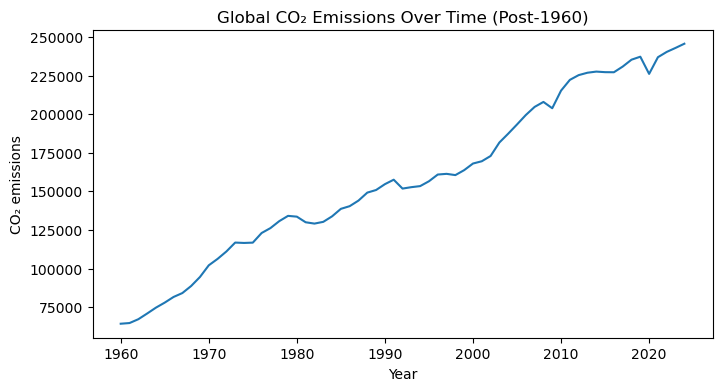

In [27]:
global_co2 = (
    df
    .groupby("year")["co2"]
    .sum()
    .reset_index()
)
plt.figure(figsize=(8,4))
plt.plot(global_co2["year"], global_co2["co2"])
plt.title("Global CO₂ Emissions Over Time (Post-1960)")
plt.xlabel("Year")
plt.ylabel("CO₂ emissions")
plt.show()


In this global trend shows the overall growth in CO2 emissions since 1960. 
While useful for understanding aggregate behaviour, this view masks substantial 
variation between individual countries and regions. As a result, country level 
comparisons are required to support meaningful exploratory analysis.


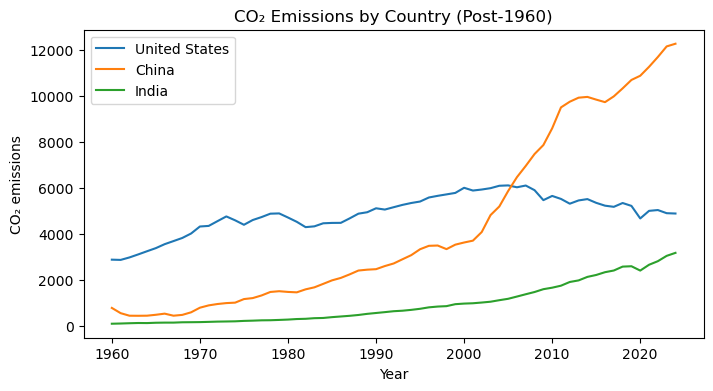

In [30]:
countries = ["United States", "China", "India"]

plt.figure(figsize=(8,4))
for country in countries:
    subset = df_analysis[df_analysis["country"] == country]
    plt.plot(subset["year"], subset["co2"], label=country)

plt.title("CO₂ Emissions by Country (Post-1960)")
plt.xlabel("Year")
plt.ylabel("CO₂ emissions")
plt.legend()
plt.show()


Compared to the global aggregate, country level trends reveal distinct emissions 
trajectories. While some countries exhibit early stabilisation or gradual change, 
others show rapid growth in recent decades. This comparison demonstrates why 
global emissions alone are insufficient for understanding regional dynamics and 
supports the inclusion of country-level exploration and comparison features in 
the dashboard. Comparison 1 Complete 


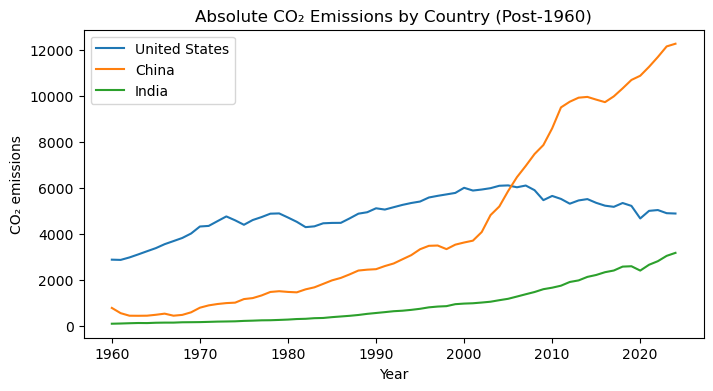

In [33]:
countries = ["United States", "China", "India"]
plt.figure(figsize=(8,4))
for country in countries:
    subset = df_analysis[df_analysis["country"] == country]
    plt.plot(subset["year"], subset["co2"], label=country)

plt.title("Absolute CO₂ Emissions by Country (Post-1960)")
plt.xlabel("Year")
plt.ylabel("CO₂ emissions")
plt.legend()
plt.show()


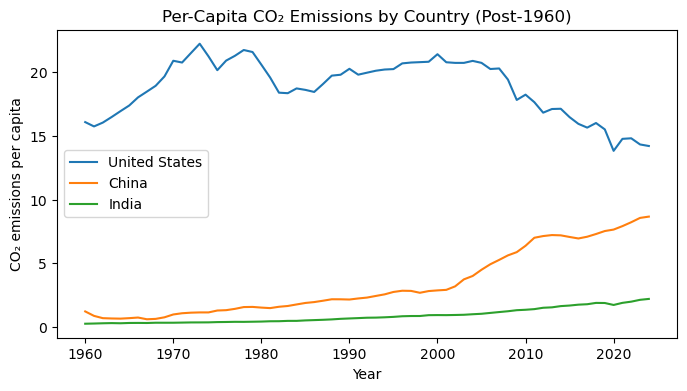

In [35]:
plt.figure(figsize=(8,4))
for country in countries:
    subset = df_analysis[df_analysis["country"] == country]
    plt.plot(subset["year"], subset["co2_per_capita"], label=country)

plt.title("Per-Capita CO₂ Emissions by Country (Post-1960)")
plt.xlabel("Year")
plt.ylabel("CO₂ emissions per capita")
plt.legend()
plt.show()


Comparing absolute and per-capita CO2 emissions highlights how different metrics 
lead to different interpretations. While total emissions emphasise overall 
contribution, per-capita emissions provide insight into individual responsibility 
and lifestyle intensity. Including both perspectives supports fairer and more 
informative comparative analysis for non expert users. Comparison 2 Complete 


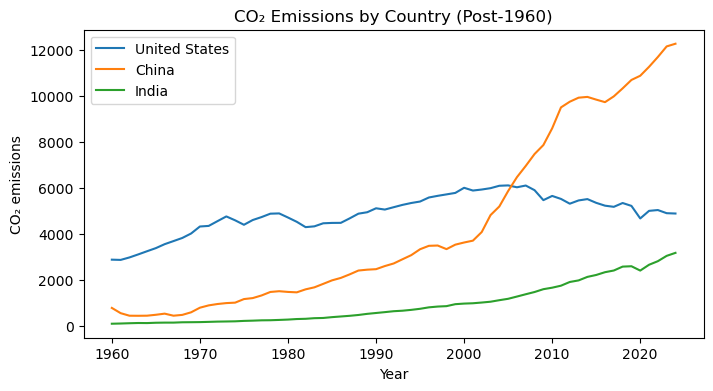

In [38]:
countries = ["United States", "China", "India"]

plt.figure(figsize=(8,4))
for country in countries:
    subset = df_analysis[df_analysis["country"] == country]
    plt.plot(subset["year"], subset["co2"], label=country)

plt.title("CO₂ Emissions by Country (Post-1960)")
plt.xlabel("Year")
plt.ylabel("CO₂ emissions")
plt.legend()
plt.show()


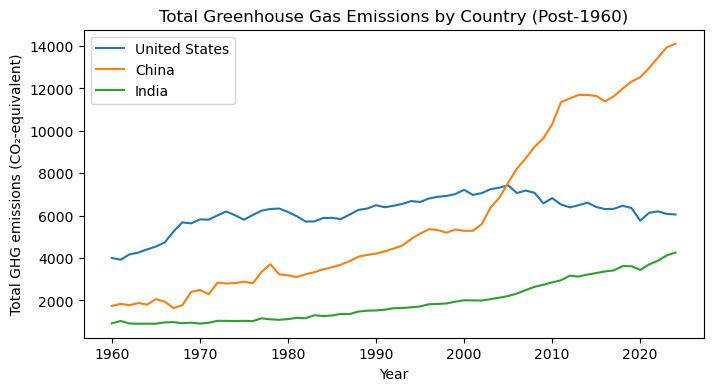

In [40]:
plt.figure(figsize=(8,4))
for country in countries:
    subset = df_analysis[df_analysis["country"] == country]
    plt.plot(subset["year"], subset["total_ghg"], label=country)

plt.title("Total Greenhouse Gas Emissions by Country (Post-1960)")
plt.xlabel("Year")
plt.ylabel("Total GHG emissions (CO₂-equivalent)")
plt.legend()
plt.show()


Comparing CO2 emissions with total greenhouse gas emissions shows that CO2 remains 
the dominant contributor to overall emissions trends across countries, while other 
greenhouse gases contribute additional variation. This supports the project’s focus 
on CO2 for predictive analysis, while retaining total GHG emissions for broader 
contextual exploration within the dashboard.Comparison 3 complete


In [43]:
!pip install pycountry_convert



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 1.1 Continent Level CO2 Emissions Comparison

To analyse regional emission patterns a continent variable was derived from country names using ISO country mappings 
Non country aggregate entries (World totals) were excluded to ensure analytical consistency  
CO2 emissions were aggregated by continent and year to allow direct temporal comparison


In [46]:
import pycountry_convert as pc

def country_to_continent(country_name):
    try:
        country_alpha2 = pc.country_name_to_country_alpha2(country_name)
        continent_code = pc.country_alpha2_to_continent_code(country_alpha2)
        continent_name = pc.convert_continent_code_to_continent_name(continent_code)
        return continent_name
    except:
        return None


In [48]:
df["continent"] = df["country"].apply(country_to_continent)


In [50]:
df["continent"].unique()


array(['Asia', None, 'Europe', 'Africa', 'North America', 'South America',
       'Oceania'], dtype=object)

In [52]:
# Remove non-country entries (e.g., World, aggregates)
df_continent = df[df["continent"].notna()].copy()

# Keep only relevant columns
df_continent = df_continent[["year", "continent", "co2"]]

# Drop missing CO2 values
df_continent = df_continent.dropna(subset=["co2"])

df_continent.head()


,year,continent,co2
0,1960,Asia,0.414
1,1961,Asia,0.491
2,1962,Asia,0.689
3,1963,Asia,0.707
4,1964,Asia,0.839


In [54]:
# Aggregate total CO2 emissions per continent per year
continent_yearly = (
    df_continent
    .groupby(["year", "continent"])["co2"]
    .sum()
    .reset_index()
)

continent_yearly.head()


,year,continent,co2
0,1960,Africa,153.787
1,1960,Asia,1539.007
2,1960,Europe,3966.050
3,1960,North America,3178.771
4,1960,Oceania,100.297


In [56]:
continent_pivot = continent_yearly.pivot(
    index="year",
    columns="continent",
    values="co2"
)
# Focus on modern industrial era (post-1960)
continent_pivot = continent_pivot[continent_pivot.index >= 1960]

continent_pivot = continent_pivot.sort_index()

continent_pivot.head()


continent,Africa,Asia,Europe,North America,Oceania,South America
year,,,,,,
1960,153.787,1539.007,3966.050,3178.771,100.297,199.141
1961,159.086,1393.835,4111.276,3173.510,100.182,201.759
1962,163.577,1342.947,4338.511,3297.492,103.294,215.628
1963,173.417,1423.514,4611.321,3431.156,109.549,219.376
1964,190.904,1507.770,4841.249,3610.417,118.717,230.143


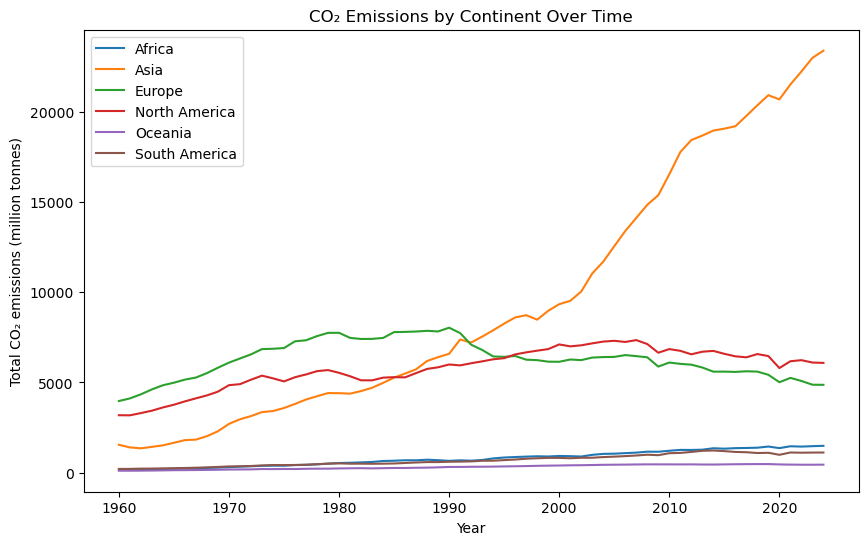

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for continent in continent_pivot.columns:
    plt.plot(continent_pivot.index,
             continent_pivot[continent],
             label=continent)

plt.title("CO₂ Emissions by Continent Over Time")
plt.xlabel("Year")
plt.ylabel("Total CO₂ emissions (million tonnes)")
plt.legend()
plt.show()


### Interpretation

From 1960 onwards, Asia shows the most dramatic increase in CO2 emissions, particularly post-2000, reflecting rapid industrialisation and economic expansion.

Europe and North America exhibit stabilisation or decline in recent decades, suggesting structural economic transitions and climate policy interventions.

Africa and South America demonstrate gradual increases, but remain substantially lower in total emissions compared to Asia, Europe, and North America.

This comparison highlights the shift in global emissions dominance from Western economies to rapidly developing Asian economies.


## Comparison 1.2 High Population Countries (Total vs Per Capita CO2)

In this section it compares CO2 emissions trends for the world's most populous countries:
China, India, USA, Indonesia and Pakistan.

Both total CO2 emissions and per capita CO2 emissions are analysed to distinguish between absolute contribution and individual level intensity


In [62]:
countries = ["China", "India", "United States", "Indonesia", "Pakistan"]

df_pop = df[df["country"].isin(countries)].copy()

# Focus on modern industrial period
df_pop = df_pop[df_pop["year"] >= 1960]

df_pop = df_pop.dropna(subset=["co2", "co2_per_capita"])


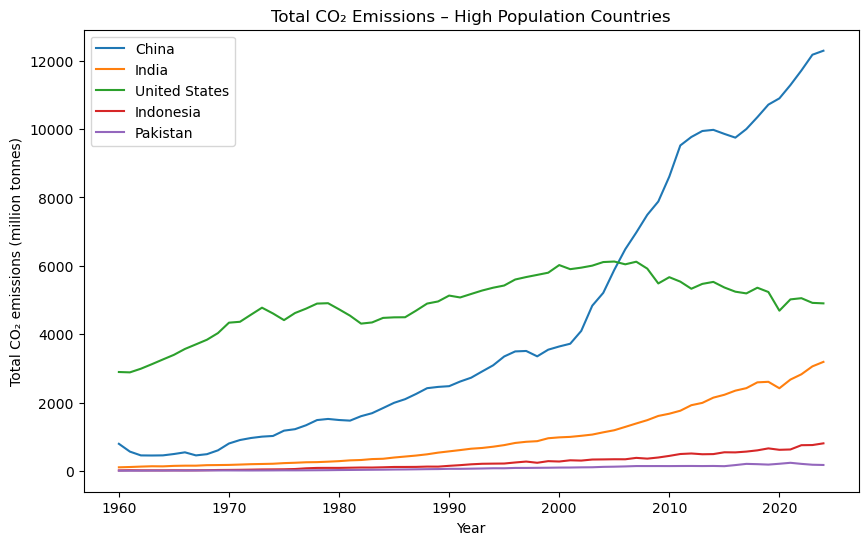

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for country in countries:
    country_data = df_pop[df_pop["country"] == country]
    plt.plot(country_data["year"], country_data["co2"], label=country)

plt.title("Total CO₂ Emissions – High Population Countries")
plt.xlabel("Year")
plt.ylabel("Total CO₂ emissions (million tonnes)")
plt.legend()
plt.show()


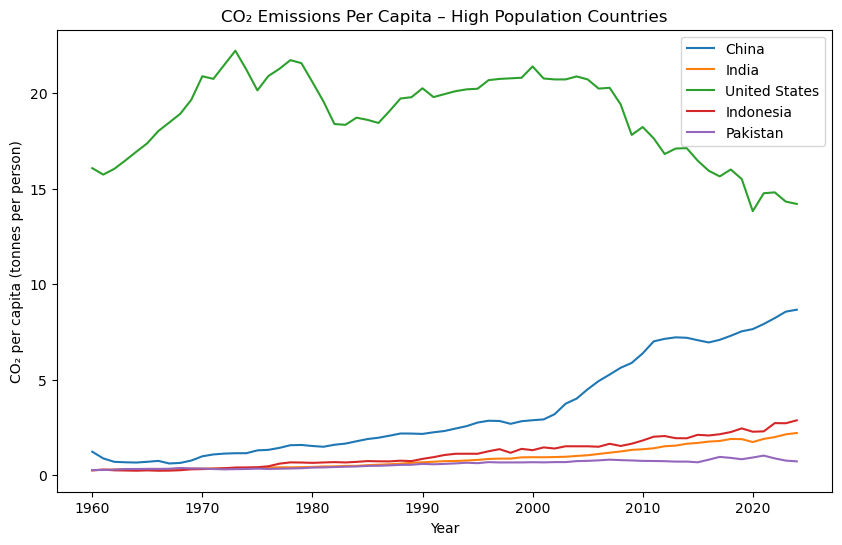

In [66]:
plt.figure(figsize=(10,6))

for country in countries:
    country_data = df_pop[df_pop["country"] == country]
    plt.plot(country_data["year"], country_data["co2_per_capita"], label=country)

plt.title("CO₂ Emissions Per Capita – High Population Countries")
plt.xlabel("Year")
plt.ylabel("CO₂ per capita (tonnes per person)")
plt.legend()
plt.show()


### Analysis

The comparison highlights significant divergence between total emissions and per capita emissions

- China shows the largest absolute growth in total CO2 emissions since 2000
- The United States maintains high per capita emissions despite slower total growth
- India, Indonesia and Pakistan show rising total emissions but substantially lower per capita levels compared to developed economies

This demonstrates the importance of contextualising total emissions with population size, supporting the dashboard’s goal of improving interpretability for non expert users.


## Comparison 1.3 BRICS vs OECD vs Scandinavia CO2 Emissions


To examine structural differences between emerging and developed economies, CO2 emissions are aggregated for BRICS countries and compared against a representative subset of OECD member countries. Also, Scandinavian countries (Sweden, Norway, and Denmark) are analysed separately to explore how smaller, highly developed economies with strong sustainability policies differ in emissions patterns.

The analysis focuses on the post-1960 period to reflect the modern industrial era and capture long-term structural shifts in global emissions contributions.


In [70]:
# Define BRICS countries
brics = ["Brazil", "Russia", "India", "China", "South Africa"]

# Define major OECD countries (representative subset)
oecd = [
    "United States", "Germany", "France", "United Kingdom",
    "Japan", "Canada", "Australia", "Italy"
]

# Define Scandinavian countries
scandinavia = ["Sweden", "Norway", "Denmark"]


In [72]:
df_bloc = df[df["country"].isin(brics + oecd + scandinavia)].copy()

df_bloc = df_bloc[df_bloc["year"] >= 1960]

df_bloc = df_bloc.dropna(subset=["co2"])


In [74]:
def classify_bloc(country):
    if country in brics:
        return "BRICS"
    elif country in scandinavia:
        return "Scandinavia"
    else:
        return "OECD"

df_bloc["bloc"] = df_bloc["country"].apply(classify_bloc)

bloc_yearly = (
    df_bloc
    .groupby(["year", "bloc"])["co2"]
    .sum()
    .reset_index()
)

bloc_pivot = bloc_yearly.pivot(
    index="year",
    columns="bloc",
    values="co2"
)

bloc_pivot = bloc_pivot.sort_index()


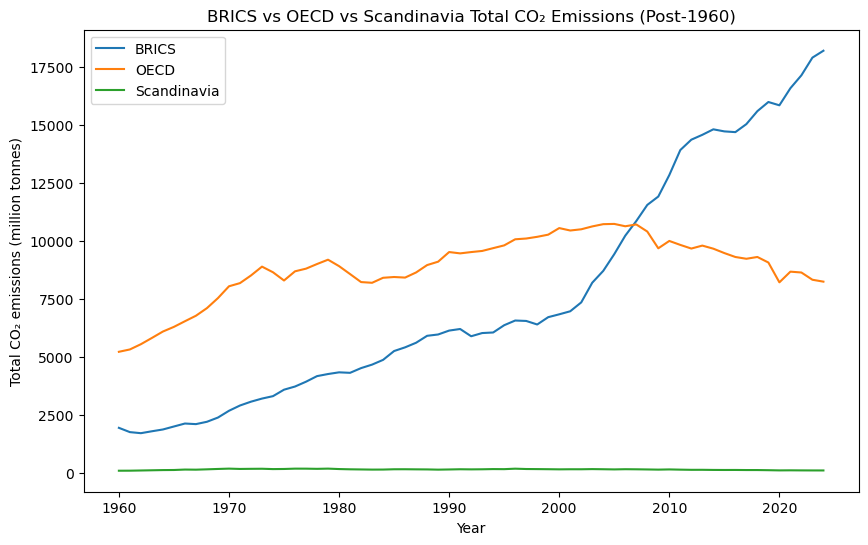

In [76]:
plt.figure(figsize=(10,6))

for bloc in bloc_pivot.columns:
    plt.plot(bloc_pivot.index, bloc_pivot[bloc], label=bloc)

plt.title("BRICS vs OECD vs Scandinavia Total CO₂ Emissions (Post-1960)")
plt.xlabel("Year")
plt.ylabel("Total CO₂ emissions (million tonnes)")
plt.legend()
plt.show()


### Analysis

The comparison reveals a clear structural shift in global emissions contributions over time.

OECD countries in this representative subset historically dominated total CO2 emissions during the late 20th century. However, from approximately 2000 onwards, BRICS emissions increase sharply, largely driven by rapid industrial expansion in China and India. This results in BRICS surpassing OECD emissions in the 21st century.

In contrast, Scandinavian countries maintain substantially lower total emissions throughout the entire period. This reflects both smaller population sizes and earlier adoption of energy transition policies, demonstrating a different development emissions trajectory compared to both BRICS and larger OECD economies.

Overall, the results highlight a transition in global emissions growth from developed to emerging economies, while also illustrating how policy orientation and economic structure influence long-term emissions patterns.



In [79]:
bloc_pivot.head()


bloc,BRICS,OECD,Scandinavia
year,,,
1960,1939.900,5215.414,92.019
1961,1755.048,5316.641,93.851
1962,1709.473,5542.647,102.238
1963,1791.870,5812.279,110.957
1964,1868.958,6088.397,119.696
